   amfi_code        date       nav  previous_nav  daily_return
0     100016  2022-01-03  520.4608           NaN           NaN
1     100016  2022-01-04  515.0971      520.4608     -0.010306
2     100016  2022-01-05  521.7239      515.0971      0.012865
3     100016  2022-01-06  515.7880      521.7239     -0.011377
4     100016  2022-01-07  515.1639      515.7880     -0.001210
5     100016  2022-01-10  510.7136      515.1639     -0.008639
6     100016  2022-01-11  513.5542      510.7136      0.005562
7     100016  2022-01-12  512.3195      513.5542     -0.002404
8     100016  2022-01-13  510.2445      512.3195     -0.004050
9     100016  2022-01-14  514.3636      510.2445      0.008073
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


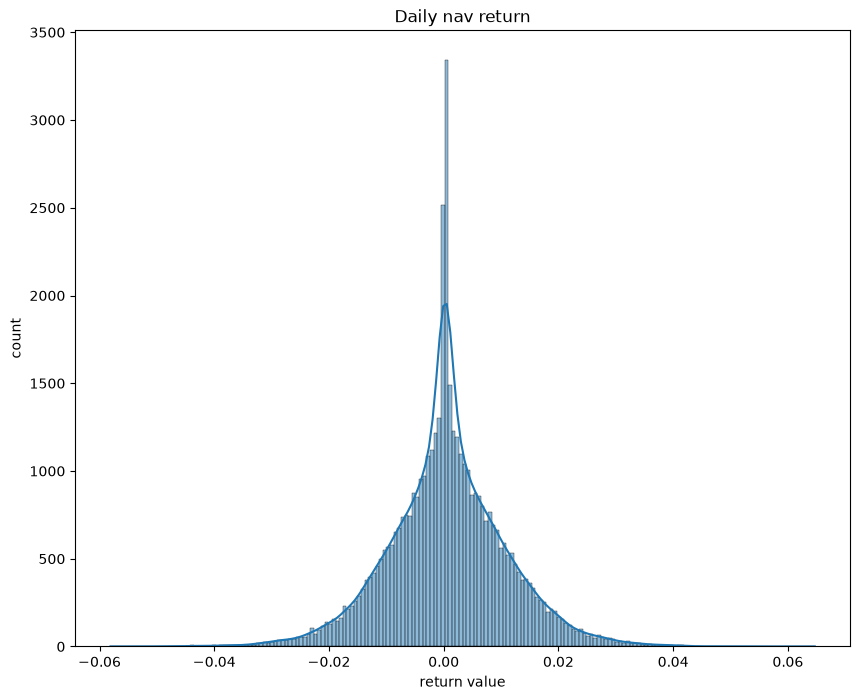

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/processed/nav_history_clean.csv")

df=df.sort_values(by=['amfi_code','date'])


df['previous_nav']=df.groupby('amfi_code')['nav'].shift(1)
   

df['daily_return']=(df['nav']/df['previous_nav'])-1

print(df.head(10))

print(df['daily_return'].describe())


plt.figure(figsize=(10,8))

sns.histplot(
    data=df,
    x='daily_return',
    
    kde=True
)

plt.title('Daily nav return')
plt.xlabel('return value')
plt.ylabel('count')

plt.show()

#saving file

df.to_csv("../data/processed/nav_history_daily_returns.csv", index=False)



In [16]:
import pandas as pd

# ---------------------------------------
# STEP 1: Load dataset
# ---------------------------------------
df = pd.read_csv("../data/processed/nav_history_clean.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["amfi_code", "date"])

# ---------------------------------------
# STEP 2: Latest available date
# ---------------------------------------
latest_date = df["date"].max()

# CAGR periods
periods = {
    "CAGR_1Y": 1,
    "CAGR_3Y": 3,
    "CAGR_5Y": 5
}

results = []

# ---------------------------------------
# STEP 3: Calculate CAGR
# ---------------------------------------
for fund in df["amfi_code"].unique():

    fund_data = df[df["amfi_code"] == fund].copy()
    

    # End NAV (latest available NAV)
    end_row = fund_data.iloc[-1]
    end_nav = end_row["nav"]
    end_date = end_row["date"]

    row = {
        "amfi_code": fund
    }

    for period_name, years in periods.items():

        # Required start date
        target_date = end_date - pd.DateOffset(years=years)
       

        # Find first NAV on or after target date
        start_rows = fund_data[fund_data["date"] >= target_date]
        

        if start_rows.empty:
            row[period_name] = None
            continue

        start_row = start_rows.iloc[0]

        start_nav = start_row["nav"]

        cagr = (end_nav / start_nav) ** (1 / years) - 1

        row[period_name] = cagr
        

    results.append(row)

# ---------------------------------------
# STEP 4: Create comparison table
# ---------------------------------------
comparison_table = pd.DataFrame(results)

# Convert to percentage
comparison_table["CAGR_1Y"] = comparison_table["CAGR_1Y"] * 100
comparison_table["CAGR_3Y"] = comparison_table["CAGR_3Y"] * 100
comparison_table["CAGR_5Y"] = comparison_table["CAGR_5Y"] * 100

# Round values
comparison_table = comparison_table.round(2)

# ---------------------------------------
# STEP 5: Sort by Fund ID
# ---------------------------------------
comparison_table = comparison_table.sort_values("amfi_code")

# ---------------------------------------
# STEP 6: Display results
# ---------------------------------------
print(comparison_table)


    amfi_code  CAGR_1Y  CAGR_3Y  CAGR_5Y
0      100016    -2.22     1.29     2.32
1      100025     3.70     3.92     3.91
2      100033    53.23    32.44    26.07
3      101206    47.92    28.97    20.44
4      101207   -23.99    -4.15     6.95
5      101208     7.24     6.32     5.71
6      102885    20.21    19.67    15.88
7      102886   -16.80    -0.77     1.03
8      102887    13.58    25.56    14.68
9      118632    33.98    22.65    20.88
10     118633    25.54    21.09    14.19
11     118634    15.81     8.01    14.27
12     118635    22.49    20.01    13.91
13     118636    10.45     4.06     4.66
14     119092     1.61     0.53     5.58
15     119093    19.77    20.82     6.92
16     119094    22.26    35.11    24.45
17     119095   -42.80   -11.71     1.34
18     119120     5.52     5.84     5.16
19     119551    60.44    30.46    22.38
20     119552     5.71    16.27    18.71
21     119598    82.78    26.67    28.03
22     119599    13.95    -1.34     1.81
23     120503   

In [ ]:
#Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds. 
import numpy as np

# ---------------------------------------
# STEP 1: Load dataset
# ---------------------------------------
df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# ---------------------------------------
# STEP 2: Remove missing daily returns
# ---------------------------------------
df = df.dropna(subset=["daily_return"])

# ---------------------------------------
# STEP 3: Risk-free rate
# ---------------------------------------
annual_rf = 0.065          # 6.5% annual
daily_rf = annual_rf / 252 # Daily risk-free rate

# ---------------------------------------
# STEP 4: Calculate Sharpe Ratio
# ---------------------------------------
results = []

for fund in df["amfi_code"].unique():

    fund_data = df[df["amfi_code"] == fund]

    # Average daily return
    mean_return = fund_data["daily_return"].mean()

    # Daily standard deviation
    std_return = fund_data["daily_return"].std()

    # Skip funds with zero volatility
    if std_return == 0 or np.isnan(std_return):
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "Average_Daily_Return": mean_return,
        "Daily_Std_Dev": std_return,
        "Sharpe_Ratio": sharpe
    })

# ---------------------------------------
# STEP 5: Create DataFrame
# ---------------------------------------
sharpe_df = pd.DataFrame(results)

# ---------------------------------------
# STEP 6: Rank Funds
# ---------------------------------------
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

# ---------------------------------------
# STEP 7: Round values
# ---------------------------------------
sharpe_df = sharpe_df.round({
    "Average_Daily_Return": 6,
    "Daily_Std_Dev": 6,
    "Sharpe_Ratio": 3
})

# Arrange columns
sharpe_df = sharpe_df[
    [
        "Rank",
        "amfi_code",
        "Average_Daily_Return",
        "Daily_Std_Dev",
        "Sharpe_Ratio"
    ]
]

# ---------------------------------------
# STEP 8: Display Results
# ---------------------------------------
print(sharpe_df)

# ---------------------------------------
# STEP 9: Save CSV
# ---------------------------------------
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio_ranking.csv",
    index=False
)

print("\nSharpe Ratio ranking saved successfully!")

    Rank  amfi_code  Average_Daily_Return  Daily_Std_Dev  Sharpe_Ratio
34     1     148567              0.001074       0.008941         1.448
30     2     120843              0.001082       0.010008         1.307
36     3     148569              0.001124       0.011134         1.235
19     4     119551              0.000917       0.008656         1.208
25     5     120505              0.001161       0.012152         1.180
38     6     149323              0.001055       0.011179         1.132
2      7     100033              0.001080       0.011929         1.094
9      8     118632              0.000865       0.008913         1.082
3      9     101206              0.000852       0.009177         1.027
24    10     120504              0.000843       0.009048         1.027
16    11     119094              0.001027       0.012225         0.998
20    12     119552              0.000785       0.008781         0.953
39    13     149324              0.001194       0.015648         0.950
21    

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Remove missing returns
df = df.dropna(subset=["daily_return"])


annual_rf = 0.065          # 6.5% annual
daily_rf = annual_rf / 252

results = []

#  Calculate Sortino Ratio

for fund in df["amfi_code"].unique():

    fund_data = df[df["amfi_code"] == fund]

    # Average daily return
    mean_return = fund_data["daily_return"].mean()

    # Only negative return days
    downside_returns = fund_data[
        fund_data["daily_return"] < 0
    ]["daily_return"]

    # Downside standard deviation
    downside_std = downside_returns.std()

    # Calculate Sortino Ratio
    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "Average_Daily_Return": mean_return,
        "Downside_Std_Dev": downside_std,
        "Sortino_Ratio": sortino
    })




sortino_df = pd.DataFrame(results)

#  Rank Funds

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df["Rank"] = range(1, len(sortino_df) + 1)


sortino_df = sortino_df.round({
    "Average_Daily_Return": 6,
    "Downside_Std_Dev": 6,
    "Sortino_Ratio": 3
})

# Rearrange columns
sortino_df = sortino_df[
    [
        "Rank",
        "amfi_code",
        "Average_Daily_Return",
        "Downside_Std_Dev",
        "Sortino_Ratio"
    ]
]

print(sortino_df)


sortino_df.to_csv(
    "../data/processed/sortino_ratio_ranking.csv",
    index=False
)

print("\nSortino Ratio ranking saved successfully!")

    Rank  amfi_code  Average_Daily_Return  Downside_Std_Dev  Sortino_Ratio
34     1     148567              0.001074          0.005428          2.386
30     2     120843              0.001082          0.005531          2.364
36     3     148569              0.001124          0.006404          2.147
19     4     119551              0.000917          0.004887          2.140
25     5     120505              0.001161          0.007067          2.029
38     6     149323              0.001055          0.006750          1.875
9      7     118632              0.000865          0.005211          1.850
2      8     100033              0.001080          0.007133          1.829
24     9     120504              0.000843          0.005145          1.805
3     10     101206              0.000852          0.005238          1.800
16    11     119094              0.001027          0.007163          1.704
21    12     119598              0.001201          0.008936          1.675
35    13     148568      

In [19]:
import pandas as pd
df=pd.read_csv('../data/raw/10_benchmark_indices.csv')
df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [1]:
import pandas as pd
from scipy.stats import linregress

# ---------------------------------------------
# STEP 1 : Load Fund Daily Returns
# ---------------------------------------------
fund_df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

fund_df["date"] = pd.to_datetime(fund_df["date"])

fund_df = fund_df.dropna(subset=["daily_return"])

# ---------------------------------------------
# STEP 2 : Load NIFTY Data
# ---------------------------------------------
nifty = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nifty["date"] = pd.to_datetime(nifty["date"])

# Sort by date
nifty = nifty.sort_values("date")
# Keep only NIFTY100 data
nifty = nifty[
    nifty["index_name"] == "NIFTY100"
].copy()

# ---------------------------------------------
# STEP 3 : Calculate NIFTY Daily Returns
# ---------------------------------------------
nifty["nifty_return"] = nifty["close_value"].pct_change()

nifty = nifty.dropna(subset=["nifty_return"])

# ---------------------------------------------
# STEP 4 : Merge Fund Returns with NIFTY Returns
# ---------------------------------------------
merged = pd.merge(
    fund_df,
    nifty[["date", "nifty_return"]],
    on="date",
    how="inner"
)

# ---------------------------------------------
# STEP 5 : Calculate Alpha & Beta
# ---------------------------------------------
results = []

for fund in merged["amfi_code"].unique():

    temp = merged[
        merged["amfi_code"] == fund
    ]

    regression = linregress(
        temp["nifty_return"],
        temp["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    r_squared = regression.rvalue ** 2

    p_value = regression.pvalue

    std_error = regression.stderr

    results.append({

        "amfi_code": fund,

        "Alpha": alpha,

        "Beta": beta,

        "R_squared": r_squared,

        "P_value": p_value,

        "Std_Error": std_error

    })

# ---------------------------------------------
# STEP 6 : Create DataFrame
# ---------------------------------------------
alpha_beta = pd.DataFrame(results)

# Round values
alpha_beta = alpha_beta.round({

    "Alpha":4,

    "Beta":4,

    "R_squared":4,

    "P_value":6,

    "Std_Error":6

})

# ---------------------------------------------
# STEP 7 : Rank by Alpha
# ---------------------------------------------
alpha_beta = alpha_beta.sort_values(
    by="Alpha",
    ascending=False
)

alpha_beta["Rank"] = range(
    1,
    len(alpha_beta)+1
)

alpha_beta = alpha_beta[
    [
        "Rank",
        "amfi_code",
        "Alpha",
        "Beta",
        "R_squared",
        "P_value",
        "Std_Error"
    ]
]

# ---------------------------------------------
# STEP 8 : Print Result
# ---------------------------------------------
print(alpha_beta)

# ---------------------------------------------
# STEP 9 : Save CSV
# ---------------------------------------------
alpha_beta.to_csv(
    "../data/processed/alpha_beta_results.csv",
    index=False
)

print("Alpha-Beta calculation completed successfully.")

    Rank  amfi_code   Alpha    Beta  R_squared   P_value  Std_Error
21     1     119598  0.3034 -0.0232     0.0001  0.687179   0.057589
39     2     149324  0.3006  0.0115     0.0000  0.840494   0.056904
25     3     120505  0.2926  0.0005     0.0000  0.990090   0.044192
36     4     148569  0.2827  0.0181     0.0002  0.654295   0.040485
30     5     120843  0.2733 -0.0228     0.0003  0.530528   0.036388
2      6     100033  0.2720  0.0051     0.0000  0.906369   0.043381
34     7     148567  0.2698  0.0237     0.0005  0.466427   0.032508
38     8     149323  0.2660 -0.0025     0.0000  0.950525   0.040653
16     9     119094  0.2608 -0.0663     0.0019  0.135988   0.044415
19    10     119551  0.2320 -0.0318     0.0009  0.313143   0.031465
9     11     118632  0.2183 -0.0084     0.0001  0.796646   0.032411
3     12     101206  0.2140  0.0211     0.0003  0.527551   0.033368
24    13     120504  0.2119  0.0162     0.0002  0.621855   0.032902
35    14     148568  0.2087 -0.0264     0.0005  

In [2]:
#Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range. code for copy and paste
import pandas as pd

# ---------------------------------------------------
# STEP 1 : Load Dataset
# ---------------------------------------------------
df = pd.read_csv("../data/processed/nav_history_clean.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["amfi_code", "date"])

results = []

# ---------------------------------------------------
# STEP 2 : Calculate Maximum Drawdown
# ---------------------------------------------------
for fund in df["amfi_code"].unique():

    fund_data = df[df["amfi_code"] == fund].copy()

    # Running maximum NAV
    fund_data["running_max"] = fund_data["nav"].cummax()

    # Drawdown
    fund_data["drawdown"] = (
        fund_data["nav"] /
        fund_data["running_max"]
    ) - 1

    # Worst drawdown row
    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    max_drawdown = worst_row["drawdown"]

    trough_date = worst_row["date"]

    # Running max value at the trough
    peak_nav = worst_row["running_max"]

    # Find the first date when this peak NAV occurred
    peak_date = fund_data[
        fund_data["nav"] == peak_nav
    ].iloc[0]["date"]

    results.append({

        "amfi_code": fund,

        "Peak_Date": peak_date,

        "Trough_Date": trough_date,

        "Maximum_Drawdown": max_drawdown

    })

# ---------------------------------------------------
# STEP 3 : Create DataFrame
# ---------------------------------------------------
mdd_df = pd.DataFrame(results)

# Convert to percentage
mdd_df["Maximum_Drawdown"] = (
    mdd_df["Maximum_Drawdown"] * 100
)

# Round values
mdd_df["Maximum_Drawdown"] = (
    mdd_df["Maximum_Drawdown"].round(2)
)

# ---------------------------------------------------
# STEP 4 : Rank Funds
# (Least negative drawdown is ranked highest)
# ---------------------------------------------------
mdd_df = mdd_df.sort_values(
    by="Maximum_Drawdown",
    ascending=False
)

mdd_df["Rank"] = range(
    1,
    len(mdd_df)+1
)

mdd_df = mdd_df[
    [
        "Rank",
        "amfi_code",
        "Peak_Date",
        "Trough_Date",
        "Maximum_Drawdown"
    ]
]

# ---------------------------------------------------
# STEP 5 : Display Results
# ---------------------------------------------------
print(mdd_df)

# ---------------------------------------------------
# STEP 6 : Save CSV
# ---------------------------------------------------
mdd_df.to_csv(
    "../data/processed/maximum_drawdown_results.csv",
    index=False
)

print("\nMaximum Drawdown calculation completed successfully.")

    Rank  amfi_code  Peak_Date Trough_Date  Maximum_Drawdown
27     1     120507 2025-10-16  2025-10-20             -0.10
31     2     120844 2024-04-12  2024-04-30             -0.12
5      3     101208 2023-09-05  2023-09-12             -0.16
1      4     100025 2023-05-23  2023-07-28             -4.31
18     5     119120 2024-09-16  2025-04-01             -4.33
13     6     118636 2023-02-09  2024-02-09             -8.32
6      7     102885 2022-02-03  2022-03-29            -10.86
34     8     148567 2023-07-11  2023-10-20            -11.27
3      9     101206 2023-04-24  2023-07-05            -11.29
12    10     118635 2022-01-03  2022-06-09            -11.65
20    11     119552 2024-05-21  2024-09-02            -11.80
24    12     120504 2022-10-04  2023-05-30            -12.59
30    13     120843 2022-03-07  2022-04-13            -12.97
23    14     120503 2023-09-19  2023-11-09            -13.90
14    15     119092 2023-10-12  2025-02-07            -14.40
37    16     149322 2022

In [ ]:
import pandas as pd

# ---------------------------------------------------
# STEP 1 : Load Fund Metrics Dataset
# ---------------------------------------------------
df = pd.read_csv("../data/raw/07_scheme_performance.csv")   # Change path if needed

# ---------------------------------------------------
# STEP 2 : Create Ranks
# ---------------------------------------------------

# Higher return is better
df["return_rank"] = df["return_3yr_pct"].rank(
    ascending=False,
    method="min"
)

# Higher Sharpe is better
df["sharpe_rank"] = df["sharpe_ratio"].rank(
    ascending=False,
    method="min"
)

# Higher Alpha is better
df["alpha_rank"] = df["alpha"].rank(
    ascending=False,
    method="min"
)

# Lower Expense Ratio is better
df["expense_rank"] = df["expense_ratio_pct"].rank(
    ascending=True,
    method="min"
)

# Lower Maximum Drawdown is better
# (less negative / smaller loss)
df["drawdown_rank"] = df["max_drawdown_pct"].rank(
    ascending=True,
    method="min"
)

# ---------------------------------------------------
# STEP 3 : Convert Ranks to Scores (0-100)
# ---------------------------------------------------

n = len(df)

df["return_score"] = ((n - df["return_rank"]) / (n - 1)) * 100
df["sharpe_score"] = ((n - df["sharpe_rank"]) / (n - 1)) * 100
df["alpha_score"] = ((n - df["alpha_rank"]) / (n - 1)) * 100
df["expense_score"] = ((n - df["expense_rank"]) / (n - 1)) * 100
df["drawdown_score"] = ((n - df["drawdown_rank"]) / (n - 1)) * 100

# ---------------------------------------------------
# STEP 4 : Calculate Composite Fund Score
# ---------------------------------------------------

df["Fund_Score"] = (

      df["return_score"] * 0.30

    + df["sharpe_score"] * 0.25

    + df["alpha_score"] * 0.20

    + df["expense_score"] * 0.15

    + df["drawdown_score"] * 0.10

)

# ---------------------------------------------------
# STEP 5 : Rank Funds
# ---------------------------------------------------

df = df.sort_values(
    by="Fund_Score",
    ascending=False
)

df["Overall_Rank"] = range(
    1,
    len(df)+1
)

# ---------------------------------------------------
# STEP 6 : Round Values
# ---------------------------------------------------

df["Fund_Score"] = df["Fund_Score"].round(2)

# ---------------------------------------------------
# STEP 7 : Display Final Scorecard
# ---------------------------------------------------

scorecard = df[
    [
        "Overall_Rank",
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "Fund_Score"
    ]
]

print(scorecard)

# ---------------------------------------------------
# STEP 8 : Save CSV
# ---------------------------------------------------

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("\nFund Scorecard created successfully!")

    Overall_Rank  amfi_code  \
3              1     119599   
22             2     120843   
21             3     120842   
29             4     101207   
2              5     119598   
34             6     148567   
9              7     100025   
14             8     120507   
12             9     120505   
11            10     120504   
35            11     148568   
6             12     125497   
33            13     102887   
23            14     120844   
18            15     118635   
16            16     118633   
26            17     119094   
38            18     149323   
13            19     120506   
37            20     149322   
4             21     119120   
7             22     100033   
5             23     100016   
8             24     125498   
28            25     101206   
17            26     118634   
15            27     118632   
30            28     101208   
25            29     119093   
1             30     119552   
27            31     119095   
19      

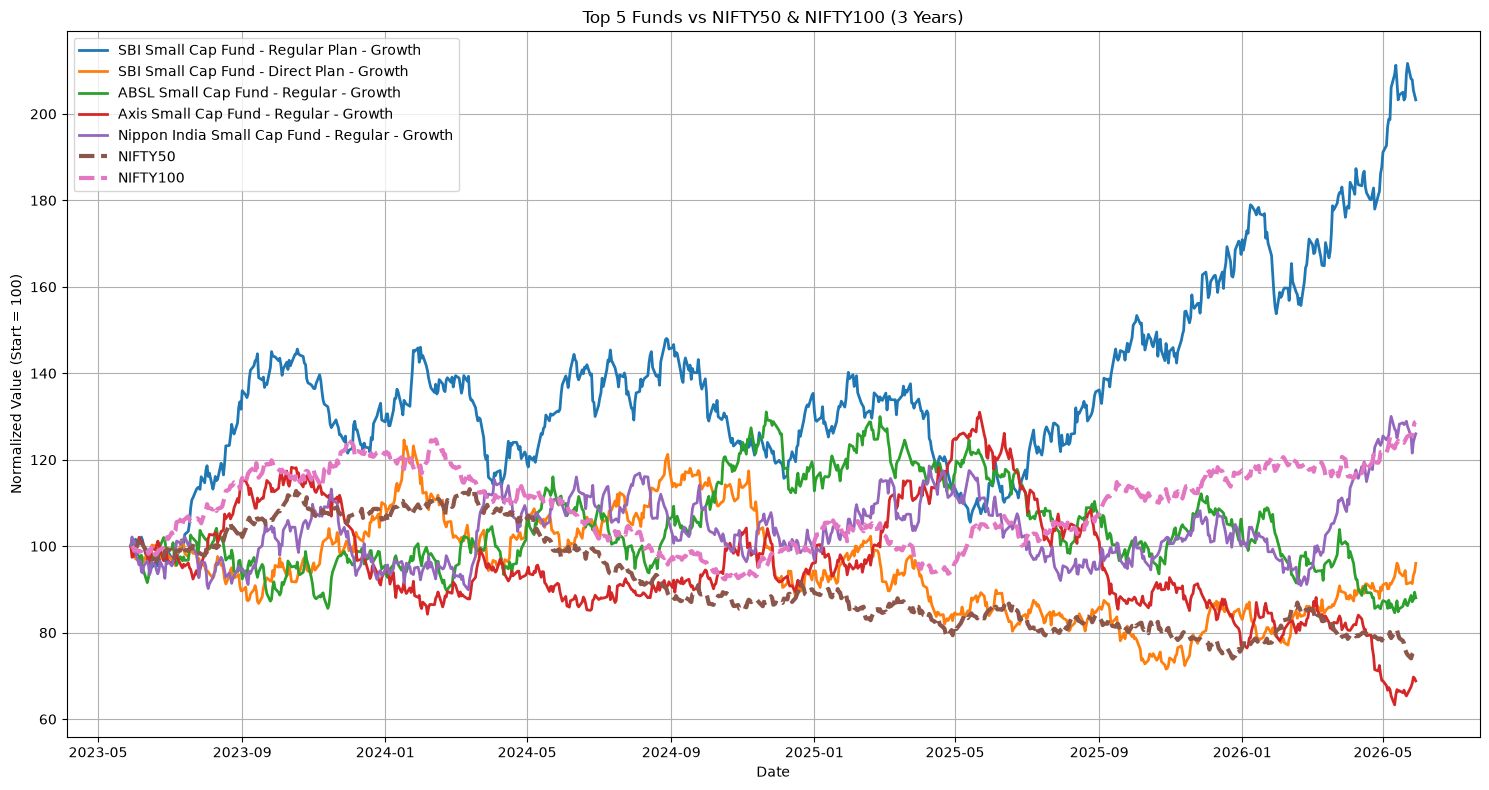

   amfi_code                                     scheme_name Benchmark  \
0     119598      SBI Small Cap Fund - Regular Plan - Growth   NIFTY50   
1     119598      SBI Small Cap Fund - Regular Plan - Growth  NIFTY100   
2     119599       SBI Small Cap Fund - Direct Plan - Growth   NIFTY50   
3     119599       SBI Small Cap Fund - Direct Plan - Growth  NIFTY100   
4     101207          ABSL Small Cap Fund - Regular - Growth   NIFTY50   
5     101207          ABSL Small Cap Fund - Regular - Growth  NIFTY100   
6     119095          Axis Small Cap Fund - Regular - Growth   NIFTY50   
7     119095          Axis Small Cap Fund - Regular - Growth  NIFTY100   
8     118634  Nippon India Small Cap Fund - Regular - Growth   NIFTY50   
9     118634  Nippon India Small Cap Fund - Regular - Growth  NIFTY100   

   Tracking_Error  
0          0.2816  
1          0.2867  
2          0.2754  
3          0.2721  
4          0.2900  
5          0.2931  
6          0.2816  
7          0.2835  
8    

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# STEP 1 : Load Fund Metrics
# ==========================================================

metrics = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Select Top 5 Funds by 3-Year Return
top5 = metrics.nlargest(5, "return_3yr_pct")

top_codes = top5["amfi_code"].tolist()

fund_names = dict(zip(top5["amfi_code"], top5["scheme_name"]))

# ==========================================================
# STEP 2 : Load NAV History
# ==========================================================

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

# Keep only Top 5 funds
nav = nav[
    nav["amfi_code"].isin(top_codes)
]

# ==========================================================
# STEP 3 : Calculate Fund Daily Returns
# ==========================================================

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav = nav.dropna(subset=["daily_return"])

# ==========================================================
# STEP 4 : Keep Last 3 Years
# ==========================================================

latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav = nav[
    nav["date"] >= start_date
]

# ==========================================================
# STEP 5 : Create Normalized Fund NAV
# ==========================================================

fund_chart = pd.DataFrame()

for code in top_codes:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    fund_chart = pd.merge(
        fund_chart,
        temp[["date", "normalized"]].rename(
            columns={
                "normalized": fund_names[code]
            }
        ),
        on="date",
        how="outer"
    ) if not fund_chart.empty else temp[
        ["date", "normalized"]
    ].rename(
        columns={
            "normalized": fund_names[code]
        }
    )

# ==========================================================
# STEP 6 : Load Benchmark Dataset
# ==========================================================

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark = benchmark[
    benchmark["date"] >= start_date
]

# ==========================================================
# STEP 7 : Calculate Benchmark Returns
# ==========================================================

benchmark["daily_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

benchmark = benchmark.dropna()

# ==========================================================
# STEP 8 : Normalize Benchmarks
# ==========================================================

benchmark_chart = pd.DataFrame()

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[
        benchmark["index_name"] == idx
    ].copy()

    temp["normalized"] = (
        temp["close_value"] /
        temp["close_value"].iloc[0]
    ) * 100

    benchmark_chart = pd.merge(
        benchmark_chart,
        temp[["date", "normalized"]].rename(
            columns={
                "normalized": idx
            }
        ),
        on="date",
        how="outer"
    ) if not benchmark_chart.empty else temp[
        ["date", "normalized"]
    ].rename(
        columns={
            "normalized": idx
        }
    )

# ==========================================================
# STEP 9 : Plot Comparison
# ==========================================================

plt.figure(figsize=(15,8))

for col in fund_chart.columns[1:]:

    plt.plot(
        fund_chart["date"],
        fund_chart[col],
        linewidth=2,
        label=col
    )

for col in benchmark_chart.columns[1:]:

    plt.plot(
        benchmark_chart["date"],
        benchmark_chart[col],
        linestyle="--",
        linewidth=3,
        label=col
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")

plt.ylabel("Normalized Value (Start = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 10 : Tracking Error
# ==========================================================

tracking_results = []

for code in top_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        bench = benchmark[
            benchmark["index_name"] == benchmark_name
        ][["date", "daily_return"]]

        merged = pd.merge(
            fund,
            bench,
            on="date",
            suffixes=(
                "_fund",
                "_benchmark"
            )
        )

        tracking_error = (
            (
                merged["daily_return_fund"] -
                merged["daily_return_benchmark"]
            ).std()
        ) * np.sqrt(252)

        tracking_results.append({

            "amfi_code": code,

            "scheme_name": fund_names[code],

            "Benchmark": benchmark_name,

            "Tracking_Error": tracking_error

        })

# ==========================================================
# STEP 11 : Save Results
# ==========================================================

tracking_df = pd.DataFrame(tracking_results)

tracking_df["Tracking_Error"] = (
    tracking_df["Tracking_Error"]
    .round(4)
)

print(tracking_df)

tracking_df.to_csv(
    "../data/processed/tracking_error_results.csv",
    index=False
)

print("\nTracking Error calculation completed successfully.")